# Geração de Dados Sintéticos com Multi-Armed Bandit
### Datathon 7-MLET — Etapa 2 + 3

---

Este notebook se baseia no que foi realizado na primeira versão e realiza novos testes a fim de buscar mais EVENTS a fim de atender esses 2 requisitos do projeto:

1. **Etapa 2.1** — Definir catálogo de ofertas, usando o EDA para justificar os boosts de cada oferta. 
2. **Etapa 2.2** - Rodar notebook de dados sintéticos e gerar offer_events, delayed_rewards e golden_set usando Thompson Sampling contextual.

## Célula 1 — Imports e configuração

Nada especial aqui — apenas as bibliotecas padrão de data science.

In [1]:
import json
import random
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

SEED = 42
rng  = np.random.default_rng(SEED)
random.seed(SEED)

Path("data/synthetic_enrichment").mkdir(parents=True, exist_ok=True)
Path("data/golden_set").mkdir(parents=True, exist_ok=True)
Path("reports").mkdir(exist_ok=True)

print("✓ Pronto.")

✓ Pronto.


## Célula 2 — Carregar o dataset

O Bank Marketing tem apenas **um produto** (depósito a prazo) e perfis de clientes reais.
Usamos os perfis como contexto — os produtos são criados por nós na próxima célula.

A coluna `duration` é descartada: ela só existe *depois* do contato, então usá-la
seria trapacear (vazamento temporal).

In [ ]:
CAMINHO_CSV = "bank-additional-full.csv"   # ou "bank-additional-full.csv"
SEPARADOR   = ";"

df = pd.read_csv(CAMINHO_CSV, sep=SEPARADOR)
print(f"Carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

# Descarta colunas de vazamento temporal
VAZAMENTO = ["duration","pdays","previous","poutcome",
             "emp.var.rate","cons.price.idx","cons.conf.idx",
             "euribor3m","nr.employed","contact","month","day_of_week"] 
# OBS: "contact" + "poutcome" não pode ser usado ?
# Imaginando um cenário onde o cliente já poderia ter um realizado alguma compra no passado.
df.drop(columns=[c for c in VAZAMENTO if c in df.columns], inplace=True)

CONTEXTO = ["age","job","marital","education","default","housing","loan"]
CONTEXTO = [c for c in CONTEXTO if c in df.columns]

if "y" in df.columns:
    df["y"] = df["y"].map({"yes":1,"no":0}).fillna(0).astype(int)

df = df[CONTEXTO + (["y"] if "y" in df.columns else [])].dropna().reset_index(drop=True)
print(f"Dataset final: {df.shape[0]:,} clientes")
print(f"Colunas de contexto: {CONTEXTO}")
df.head()

Carregado: 41,188 linhas × 21 colunas
Dataset final: 41,188 clientes
Colunas de contexto: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']


,age,job,marital,education,default,housing,loan,y
0,56,housemaid,married,basic.4y,no,no,no,0
1,57,services,married,high.school,unknown,no,no,0
2,37,services,married,high.school,no,yes,no,0
3,40,admin.,married,basic.6y,no,no,no,0
4,56,services,married,high.school,no,no,yes,0


## Célula 3 — Catálogo de ofertas (os "braços" do bandit)

Aqui criamos as 5 ofertas financeiras que o sistema vai aprender a distribuir.

**Importante entender:** as probabilidades abaixo são **hipóteses de domínio** —
estimativas baseadas em conhecimento do setor financeiro, não em dados reais.
O bandit vai usar essas hipóteses como ponto de partida e corrigi-las com o tempo.

Em produção real, essas probabilidades viriam de dados observados de clientes reais.

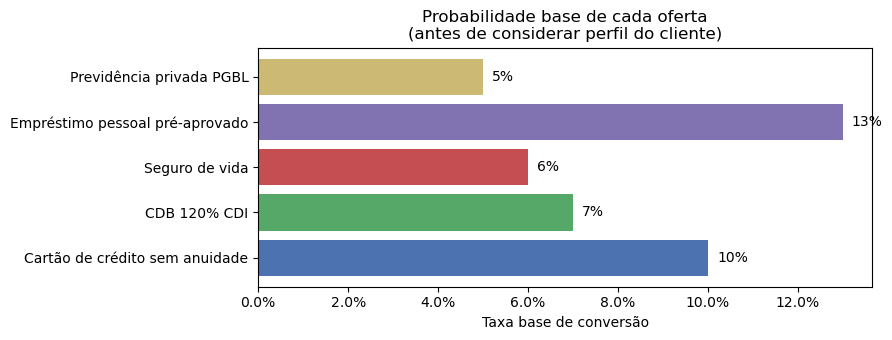

✓ Catálogo salvo: 5 ofertas


In [31]:
CATALOG = [
    {
        "offer_id":  "OFF_001",
        "name":      "Cartão de crédito sem anuidade",
        "canal":     "app_mobile",
        "base_rate": 0.10,
        # Hipótese: perfis digitais e jovens respondem melhor a cartão
        "boosts": {
            "job_admin.":      0.06,
            "job_management":  0.04,
            "job_student":     0.05,
            "edu_university":  0.04,
            "marital_single":  0.03,
            "no_loan":         0.03,
        },
        "reward_val": 1.0,
    },
    {
        "offer_id":  "OFF_002",
        "name":      "CDB 120% CDI",
        "canal":     "internet_banking",
        "base_rate": 0.07,
        # Hipótese: gestores e aposentados com capital disponível preferem renda fixa
        "boosts": {
            "job_management":  0.10,
            "job_retired":     0.08,
            "edu_university":  0.08,
            "age_senior":      0.06,
            "no_default":      0.04,
        },
        "reward_val": 2.0,
    },
    {
        "offer_id":  "OFF_003",
        "name":      "Seguro de vida",
        "canal":     "app_mobile",
        "base_rate": 0.06,
        # Hipótese: aposentados e casados com dependentes valorizam proteção
        # EDA sugere que Aposentados e Seniores têm maior propensão 
        "boosts": {
            "job_retired":      0.12,
            "age_senior":       0.08,
            "marital_married":  0.04,
            "has_housing":      0.03,
        },
        "reward_val": 2.5,
    },
    {
        "offer_id":  "OFF_004",
        "name":      "Empréstimo pessoal pré-aprovado",
        "canal":     "sms",
        "base_rate": 0.13,
        # Hipótese: trabalhadores de colarinho azul têm maior necessidade de crédito
        # Penalidade: já ter empréstimo reduz a probabilidade
        "boosts": {
            "job_blue-collar":  0.08,
            "job_services":     0.06,
            "job_housemaid":    0.05,
            "edu_basic":        0.04,
            "has_loan":        -0.05,   # boost negativo
        },
        "reward_val": 1.2,
    },
    {
        "offer_id":  "OFF_005",
        "name":      "Previdência privada PGBL",
        "canal":     "internet_banking",
        "base_rate": 0.05,
        # Hipótese: autônomos e gestores com horizonte longo têm incentivo fiscal
        # EDA Sugere que seniores tem grande propensão.
        "boosts": {
            "job_management":    0.10,
            "job_self-employed": 0.07,
            "edu_university":    0.09,
            "age_senior":        0.08, # Aumentei com base no EDA que mostrou a alta propensão antes 0.06
            "no_default":        0.04,
        },
        "reward_val": 3.0,
    },
]

OFFER_IDS = [o["offer_id"] for o in CATALOG]
OFFER_MAP = {o["offer_id"]: o for o in CATALOG}

with open("data/synthetic_enrichment/offer_catalog.json", "w", encoding="utf-8") as f:
    json.dump(CATALOG, f, ensure_ascii=False, indent=2)

# Visualiza as taxas base
fig, ax = plt.subplots(figsize=(9, 3.5))
nomes = [o["name"] for o in CATALOG]
taxas = [o["base_rate"] for o in CATALOG]
cores = ["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974" ,"#64B5CD","#8C8C8C"]
bars  = ax.barh(nomes, taxas, color=cores)
ax.set_xlabel("Taxa base de conversão")
ax.set_title("Probabilidade base de cada oferta\n(antes de considerar perfil do cliente)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, taxas):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f"{val:.0%}", va="center", fontsize=10)
plt.tight_layout()
plt.show()
print(f"✓ Catálogo salvo: {len(CATALOG)} ofertas")

## Célula 4 — Funções de perfil e probabilidade

Duas funções que todas as abordagens vão usar:

- `extrair_flags` → lê o perfil do cliente e transforma em sinais binários
- `prob_conversao` → calcula a probabilidade real de conversão (o "ground truth" da simulação)
- `segmento` → agrupa o cliente em um segmento para o bandit contextual

**Lembre-se:** `prob_conversao` é a realidade que nós definimos.
Nenhum dos algoritmos tem acesso a ela — eles só veem o resultado (converteu ou não).

In [33]:
def extrair_flags(row):
    edu = str(row.get("education", "")).lower()
    return {
        f"job_{row.get('job', '')}":    True,
        "edu_university":  "university" in edu,
        "edu_basic":       edu.startswith("basic"),
        f"marital_{row.get('marital', '')}": True,
        "age_senior":      int(row.get("age", 0)) >= 55,
        "no_default":      str(row.get("default",  "")).lower() == "no",
        "has_housing":     str(row.get("housing",  "")).lower() == "yes",
        "has_loan":        str(row.get("loan",     "")).lower() == "yes",
        "no_loan":         str(row.get("loan",     "")).lower() == "no",
        "default_unknown": str(row.get("default", "")).lower() == "unknown"
    }


def prob_conversao(flags, offer_id):
    """
    Probabilidade REAL de conversão — o ground truth da simulação.
    Nenhum algoritmo tem acesso a isso. Eles só veem o resultado final (0 ou 1).
    """
    offer = OFFER_MAP[offer_id]
    p = offer["base_rate"]
    for flag, boost in offer["boosts"].items():
        if flags.get(flag):
            p += boost
        if flags.get("default_unknown"):
            p -= 0.07 # penalidade para unknown com base no EDA
    return float(np.clip(p, 0.02, 0.95))


def segmento(row):
    """
    Agrupa o cliente em um segmento baseado em 3 dimensões.
    É isso que o bandit contextual usa para separar os aprendizados.

    Exemplo: 'management__senior__university'
             'blue-collar__mid__basic'
    """
    age = int(row.get("age", 0))
    job = str(row.get("job", "unknown"))
    edu = str(row.get("education", "")).lower()

    age_grp = "senior" if age >= 55 else ("young" if age <= 30 else "mid")
    edu_grp = "university" if "university" in edu else ("basic" if edu.startswith("basic") else "other")

    return f"{job}__{age_grp}__{edu_grp}"


# Mostra como o segmento funciona na prática
exemplos = [
    {"age":67, "job":"retired",     "education":"basic.4y",         "marital":"married", "default":"no","housing":"no","loan":"no"},
    {"age":28, "job":"student",     "education":"university.degree", "marital":"single",  "default":"no","housing":"no","loan":"no"},
    {"age":45, "job":"management",  "education":"university.degree", "marital":"married", "default":"no","housing":"yes","loan":"no"},
    {"age":38, "job":"blue-collar", "education":"basic.9y",          "marital":"married", "default":"no","housing":"yes","loan":"yes"},
    {"age":30, "job":"admin.",      "education":"university.degree", "marital":"single", "default":"unknown","housing":"yes","loan":"no"},
]

print(f"{'Cliente':<35} {'Segmento':<35} {'Melhor oferta (real)':>20}")
print("─" * 95)
for ex in exemplos:
    row  = pd.Series(ex)
    flags = extrair_flags(row)
    seg   = segmento(row)
    melhor = max(OFFER_IDS, key=lambda o: prob_conversao(flags, o))
    nome  = f"{ex['job']}, {ex['age']}a, {ex['education'][:12]}"
    print(f"{nome:<35} {seg:<35} {melhor} {OFFER_MAP[melhor]['name'][:20]}")

Cliente                             Segmento                            Melhor oferta (real)
───────────────────────────────────────────────────────────────────────────────────────────────
retired, 67a, basic.4y              retired__senior__basic              OFF_003 Seguro de vida
student, 28a, university.d          student__young__university          OFF_001 Cartão de crédito se
management, 45a, university.d       management__mid__university         OFF_002 CDB 120% CDI
blue-collar, 38a, basic.9y          blue-collar__mid__basic             OFF_004 Empréstimo pessoal p
admin., 30a, university.d           admin.__young__university           OFF_001 Cartão de crédito se


## Célula 5 — Os três algoritmos

### Por que três?

Essa é a comparação central da **Etapa 3** do projeto.

**Baseline determinístico** — regra fixa, sem aprendizado.
Sempre mostra a oferta com maior `base_rate` (empréstimo, 13%).
Não importa se o cliente é aposentado ou estudante — a oferta é sempre a mesma.

**Thompson Sampling simples** — aprende, mas sem contexto.
Mantém um contador global por oferta: quantas vezes converteu / não converteu.
O problema: mistura aposentados e estudantes no mesmo contador.
Se um aposentado rejeita o cartão, isso prejudica o cartão para estudantes também.

**Thompson Sampling contextual** — aprende por segmento.
Mantém contadores separados por segmento × oferta.
`retired__senior__basic → OFF_003` aprende separado de `student__young__university → OFF_001`
É isso que resolve o regret linear que vimos antes.

In [34]:
class BaselineDeterministico:
    """Sempre escolhe a oferta com maior taxa base. Nunca muda."""

    def __init__(self, offer_ids):
        self.offer_ids   = offer_ids
        self.best_offer  = max(offer_ids, key=lambda o: OFFER_MAP[o]["base_rate"])
        self.nome        = "Baseline fixo"

    def escolher(self, segmento_cliente=None):
        return self.best_offer

    def atualizar(self, offer_id, reward, segmento_cliente=None):
        pass  # não aprende nada


class ThompsonSimples:
    """
    Thompson Sampling sem contexto.
    Um par (alpha, beta) por oferta, compartilhado entre todos os clientes.
    """

    def __init__(self, offer_ids, seed=42):
        self.offer_ids = offer_ids
        self.rng  = np.random.default_rng(seed)
        self.nome = "Thompson Simples"
        # Prior Beta(1,1) — começa sem preferência
        self.alpha = {o: 1 for o in offer_ids}
        self.beta  = {o: 1 for o in offer_ids}

    def escolher(self, segmento_cliente=None):
        amostras = {o: self.rng.beta(self.alpha[o], self.beta[o]) for o in self.offer_ids}
        return max(amostras, key=amostras.get)

    def atualizar(self, offer_id, reward, segmento_cliente=None):
        if reward == 1: self.alpha[offer_id] += 1
        else:           self.beta[offer_id]  += 1

    def estimativas(self):
        return {o: self.alpha[o]/(self.alpha[o]+self.beta[o]) for o in self.offer_ids}


class ThompsonContextual:
    """
    Thompson Sampling com contexto.
    Um par (alpha, beta) por SEGMENTO × OFERTA.

    Isso resolve o problema do Thompson simples:
    aposentados e estudantes têm contadores separados.
    Cada segmento aprende qual oferta funciona melhor para ele.
    """

    def __init__(self, offer_ids, seed=42):
        self.offer_ids = offer_ids
        self.rng  = np.random.default_rng(seed)
        self.nome = "Thompson Contextual"
        self.alpha = {}  # chave: "segmento__offer_id"
        self.beta  = {}

    def _chave(self, seg, offer_id):
        return f"{seg}__{offer_id}"

    def _garantir(self, seg):
        """Cria contadores para um segmento novo que aparece pela primeira vez."""
        for o in self.offer_ids:
            k = self._chave(seg, o)
            if k not in self.alpha:
                self.alpha[k] = 1   # prior Beta(1,1)
                self.beta[k]  = 1

    def escolher(self, segmento_cliente):
        self._garantir(segmento_cliente)
        amostras = {
            o: self.rng.beta(self.alpha[self._chave(segmento_cliente, o)],
                             self.beta[ self._chave(segmento_cliente, o)])
            for o in self.offer_ids
        }
        return max(amostras, key=amostras.get)

    def atualizar(self, offer_id, reward, segmento_cliente):
        k = self._chave(segmento_cliente, offer_id)
        if reward == 1: self.alpha[k] += 1
        else:           self.beta[k]  += 1

    def n_segmentos(self):
        return len(self.alpha) // len(self.offer_ids)


print("✓ Três algoritmos definidos:")
print("  1. BaselineDeterministico — sem aprendizado")
print("  2. ThompsonSimples        — aprende globalmente")
print("  3. ThompsonContextual     — aprende por segmento")

✓ Três algoritmos definidos:
  1. BaselineDeterministico — sem aprendizado
  2. ThompsonSimples        — aprende globalmente
  3. ThompsonContextual     — aprende por segmento


## Célula 6 — Simulação comparativa

Rodamos os **três algoritmos em paralelo**, com os mesmos clientes e na mesma ordem.
Assim a comparação é justa — qualquer diferença de resultado vem do algoritmo, não do acaso.

⏳ Pode levar alguns segundos.

In [42]:
N_EVENTOS  = 10000
BASE_DATE  = datetime(2024, 1, 1)
MAX_LAG    = 14
TX_PENDING = 0.12

# Instancia os três algoritmos
bandits = [
    BaselineDeterministico(OFFER_IDS),
    ThompsonSimples(OFFER_IDS, seed=SEED),
    ThompsonContextual(OFFER_IDS, seed=SEED),
]

# Estruturas para guardar resultados de cada algoritmo
resultados = {b.nome: {"conversoes":[], "regret":[], "regret_acum":0.0,
                        "events":[], "rewards":[]} for b in bandits}

print(f"Simulando {N_EVENTOS:,} eventos para cada algoritmo...")

for i in range(N_EVENTOS):

    # Sorteia UM cliente — o mesmo para os três algoritmos
    row   = df.sample(n=1, random_state=int(rng.integers(0, 99999))).iloc[0]
    flags = extrair_flags(row)
    seg   = segmento(row)
    ts    = BASE_DATE + timedelta(days=int(rng.integers(0,180)),
                                  hours=int(rng.integers(8,22)),
                                  minutes=int(rng.integers(0,60)))

    # Calcula o melhor braço possível para esse cliente (para o regret)
    melhor_p = max(prob_conversao(flags, o) for o in OFFER_IDS)

    # Sorteia UM resultado aleatório — o mesmo para todos (comparação justa)
    dado_aleatorio = rng.random()

    for bandit in bandits:
        nome = bandit.nome

        # Cada bandit toma sua própria decisão
        offer_id = bandit.escolher(segmento_cliente=seg)
        p_conv   = prob_conversao(flags, offer_id)

        # Usa o mesmo dado aleatório → se p_conv for maior, converte
        converteu = int(dado_aleatorio < p_conv)
        clicou    = int(dado_aleatorio < p_conv * 0.45)

        # Regret desse round
        regret = melhor_p - p_conv
        resultados[nome]["regret_acum"] += regret
        resultados[nome]["regret"].append(resultados[nome]["regret_acum"])
        resultados[nome]["conversoes"].append(converteu)

        # Delayed reward
        if converteu:
            lag = int(rng.integers(0, MAX_LAG+1))
            pending = rng.random() < TX_PENDING
            r_status = "pending" if pending else "observed_positive"
            r_obs    = 0 if pending else 1
            lag_obs  = None if pending else lag
            ts_conv  = None if pending else (ts + timedelta(days=lag)).isoformat()
        else:
            r_status, r_obs, lag_obs, ts_conv = "observed_negative", 0, None, None

        # Bandit aprende (só com rewards observados)
        if r_status != "pending":
            bandit.atualizar(offer_id, r_obs, segmento_cliente=seg)

        # Registra eventos (só salva para o Thompson Contextual — arquivo final)
        if nome == "Thompson Contextual":
            resultados[nome]["events"].append({
                "event_id":             f"EVT_{i:07d}",
                "round":                i,
                "ctx_age":              int(row.get("age",0)),
                "ctx_job":              str(row.get("job","")),
                "ctx_marital":          str(row.get("marital","")),
                "ctx_education":        str(row.get("education","")),
                "ctx_default":          str(row.get("default","")),
                "ctx_housing":          str(row.get("housing","")),
                "ctx_loan":             str(row.get("loan","")),
                "ctx_segmento":         seg,
                "offer_id":             offer_id,
                "offer_name":           OFFER_MAP[offer_id]["name"],
                "canal":                OFFER_MAP[offer_id]["canal"],
                "p_conversao_real":     round(p_conv, 4),
                "timestamp_impression": ts.isoformat(),
                "action_click":         bool(clicou),
                "policy_version":       "v1.0-thompson-contextual",
            })
            resultados[nome]["rewards"].append({
                "event_id":     f"EVT_{i:07d}",
                "offer_id":     offer_id,
                "reward":       r_obs,
                "reward_value": OFFER_MAP[offer_id]["reward_val"] if r_obs else 0.0,
                "reward_status":r_status,
                "conversion_ts":ts_conv,
                "lag_days":     lag_obs,
            })

# Resumo rápido
print("\nResultados finais:")
print(f"{'Algoritmo':<25} {'Conversões':>12} {'Taxa':>8} {'Regret final':>14}")
print("─" * 63)
for b in bandits:
    nome  = b.nome
    convs = sum(resultados[nome]["conversoes"])
    taxa  = convs / N_EVENTOS
    reg   = resultados[nome]["regret_acum"]
    print(f"{nome:<25} {convs:>12,} {taxa:>7.1%} {reg:>14.1f}")

Simulando 10,000 eventos para cada algoritmo...

Resultados finais:
Algoritmo                   Conversões     Taxa   Regret final
───────────────────────────────────────────────────────────────
Baseline fixo                    1,268   12.7%          459.3
Thompson Simples                 1,271   12.7%          439.6
Thompson Contextual              1,417   14.2%          317.3


## Célula 7 — Gráficos de comparação

Aqui está a evidência visual que você vai mostrar na Etapa 3 e no pitch.

**O que esperar ver:**
- Regret do **baseline**: linha reta e íngreme — não aprende nunca
- Regret do **Thompson simples**: inclinação menor, mas ainda sobe linearmente
- Regret do **Thompson contextual**: curva que achata — aprende de verdade

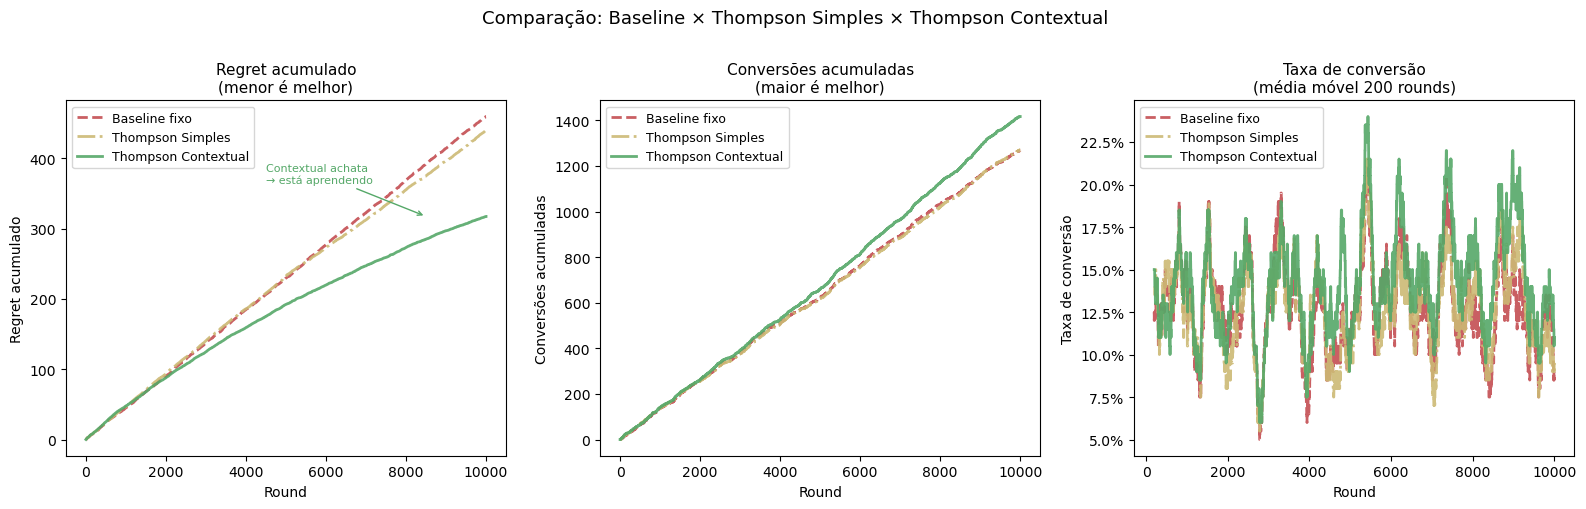

Salvo em reports/comparacao_algoritmos.png


In [43]:
cores_algo  = {"Baseline fixo":"#C44E52", "Thompson Simples":"#CCB974", "Thompson Contextual":"#55A868"}
estilo_algo = {"Baseline fixo":"--",      "Thompson Simples":"-.",       "Thompson Contextual":"-"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparação: Baseline × Thompson Simples × Thompson Contextual", fontsize=13, y=1.01)

# ── Gráfico 1: Regret acumulado ──────────────────────────────────────
ax = axes[0]
for b in bandits:
    nome = b.nome
    ax.plot(resultados[nome]["regret"],
            label=nome, color=cores_algo[nome],
            linestyle=estilo_algo[nome], linewidth=2, alpha=0.9)
ax.set_title("Regret acumulado\n(menor é melhor)", fontsize=11)
ax.set_xlabel("Round")
ax.set_ylabel("Regret acumulado")
ax.legend(fontsize=9)

# Anotação explicativa
ax.annotate("Contextual achata\n→ está aprendendo",
            xy=(N_EVENTOS*0.85, resultados["Thompson Contextual"]["regret"][-1]),
            xytext=(N_EVENTOS*0.45, resultados["Thompson Contextual"]["regret"][-1]*1.15),
            arrowprops=dict(arrowstyle="->", color="#55A868"),
            fontsize=8, color="#55A868")

# ── Gráfico 2: Conversões acumuladas ────────────────────────────────
ax = axes[1]
for b in bandits:
    nome  = b.nome
    acum  = np.cumsum(resultados[nome]["conversoes"])
    ax.plot(acum, label=nome, color=cores_algo[nome],
            linestyle=estilo_algo[nome], linewidth=2, alpha=0.9)
ax.set_title("Conversões acumuladas\n(maior é melhor)", fontsize=11)
ax.set_xlabel("Round")
ax.set_ylabel("Conversões acumuladas")
ax.legend(fontsize=9)

# ── Gráfico 3: Taxa de conversão (janela móvel de 200 rounds) ───────
ax = axes[2]
JANELA = 200
for b in bandits:
    nome = b.nome
    taxa_movel = pd.Series(resultados[nome]["conversoes"]).rolling(JANELA).mean()
    ax.plot(taxa_movel, label=nome, color=cores_algo[nome],
            linestyle=estilo_algo[nome], linewidth=2, alpha=0.9)
ax.set_title(f"Taxa de conversão\n(média móvel {JANELA} rounds)", fontsize=11)
ax.set_xlabel("Round")
ax.set_ylabel("Taxa de conversão")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("reports/comparacao_algoritmos.png", dpi=130, bbox_inches="tight")
plt.show()
print("Salvo em reports/comparacao_algoritmos.png")

## Célula 8 — O que o contextual aprendeu por segmento

Aqui vemos a diferença fundamental: o Thompson contextual mantém aprendizados
separados por segmento. Cada célula da tabela abaixo é um par (alpha, beta) independente.

Segmentos descobertos pelo bandit: 98

Segmento                                 Melhor oferta aprendida        Estimativa
─────────────────────────────────────────────────────────────────────────────────────
admin.__mid__basic                       Empréstimo pessoal pré-aprovado     17.6%
admin.__mid__other                       Cartão de crédito sem anuidade     22.0%
admin.__mid__university                  CDB 120% CDI                       17.9%
admin.__senior__basic                    CDB 120% CDI                       28.6%
admin.__senior__other                    Previdência privada PGBL           18.2%
admin.__senior__university               Previdência privada PGBL           44.4%
admin.__young__basic                     Cartão de crédito sem anuidade     25.0%
admin.__young__other                     Cartão de crédito sem anuidade     23.5%
admin.__young__university                Cartão de crédito sem anuidade     25.8%
blue-collar__mid__basic                  Empréstimo p

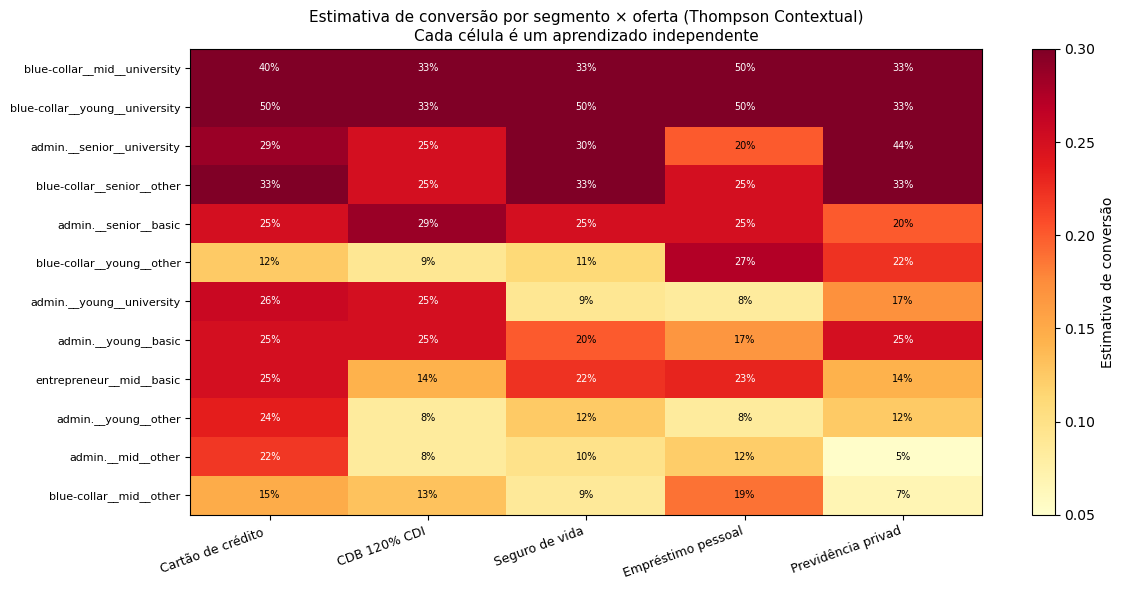

Salvo em reports/heatmap_segmentos.png


In [39]:
tc = bandits[2]  # Thompson Contextual

# Pega os segmentos que apareceram na simulação
segs_presentes = set()
for k in tc.alpha:
    seg_parte = "__".join(k.split("__")[:-1])   # remove o offer_id do final
    segs_presentes.add(seg_parte)

# Para cada segmento, mostra qual oferta o bandit aprendeu a preferir
print(f"Segmentos descobertos pelo bandit: {len(segs_presentes)}")
print()
print(f"{'Segmento':<40} {'Melhor oferta aprendida':<30} {'Estimativa':>10}")
print("─" * 85)

linhas = []
for seg in sorted(segs_presentes)[:20]:  # mostra os 20 primeiros
    estimativas_seg = {}
    for o in OFFER_IDS:
        k = f"{seg}__{o}"
        if k in tc.alpha:
            a = tc.alpha[k]; b = tc.beta[k]
            estimativas_seg[o] = a / (a + b)
    if not estimativas_seg:
        continue
    melhor_o  = max(estimativas_seg, key=estimativas_seg.get)
    melhor_p  = estimativas_seg[melhor_o]
    linhas.append((seg, melhor_o, melhor_p))
    print(f"{seg:<40} {OFFER_MAP[melhor_o]['name']:<30} {melhor_p:>9.1%}")

# Heatmap: estimativa de conversão por segmento × oferta
print()
print("Heatmap de estimativas (Thompson Contextual):")

# Pega segmentos com mais dados para o heatmap
segs_heatmap = [l[0] for l in sorted(linhas, key=lambda x:-x[2])[:12]]
nomes_ofertas = [OFFER_MAP[o]["name"][:18] for o in OFFER_IDS]
matriz = np.zeros((len(segs_heatmap), len(OFFER_IDS)))

for i, seg in enumerate(segs_heatmap):
    for j, o in enumerate(OFFER_IDS):
        k = f"{seg}__{o}"
        if k in tc.alpha:
            a = tc.alpha[k]; b = tc.beta[k]
            matriz[i, j] = a / (a + b)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(matriz, cmap="YlOrRd", aspect="auto", vmin=0.05, vmax=0.30)
ax.set_xticks(range(len(OFFER_IDS)))
ax.set_xticklabels(nomes_ofertas, rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(len(segs_heatmap)))
ax.set_yticklabels([s[:35] for s in segs_heatmap], fontsize=8)
ax.set_title("Estimativa de conversão por segmento × oferta (Thompson Contextual)\nCada célula é um aprendizado independente", fontsize=11)
plt.colorbar(im, ax=ax, label="Estimativa de conversão")

# Anota os valores
for i in range(len(segs_heatmap)):
    for j in range(len(OFFER_IDS)):
        ax.text(j, i, f"{matriz[i,j]:.0%}", ha="center", va="center", fontsize=7,
                color="white" if matriz[i,j] > 0.20 else "black")

plt.tight_layout()
plt.savefig("reports/heatmap_segmentos.png", dpi=130, bbox_inches="tight")
plt.show()
print("Salvo em reports/heatmap_segmentos.png")

## Célula 9 — Visualizar o prior Beta evoluindo

Aqui fica claro por que o contextual é diferente: para o mesmo segmento,
as distribuições Beta ficam mais estreitas e confiantes com o tempo.

Para o Thompson simples, o aprendizado é diluído por todos os perfis.

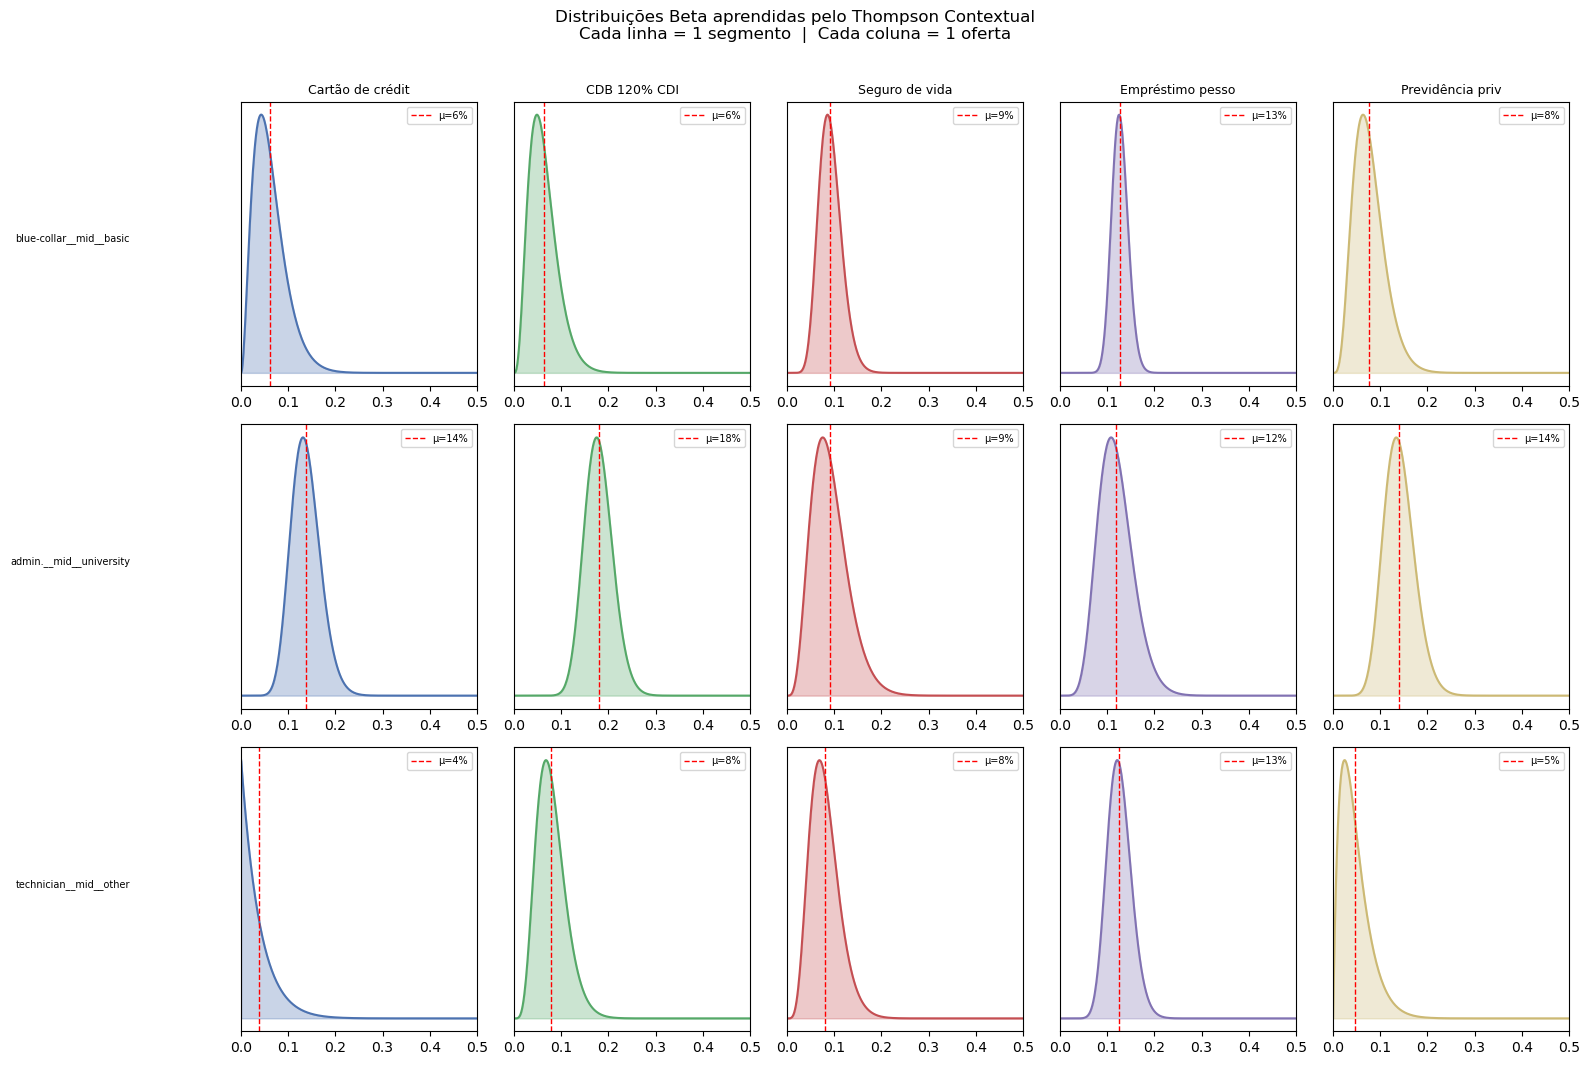

Salvo em reports/betas_por_segmento.png

Interprete: quanto mais estreita a curva, mais confiante o bandit está.
Quanto mais à direita o pico, maior a estimativa de conversão.


In [40]:
tc = bandits[2]  # Thompson Contextual

# Pega 3 segmentos interessantes que tenham dados suficientes
segs_plot = []
for k in tc.alpha:
    seg_parte = "__".join(k.split("__")[:-1])
    # Soma total de observações nesse segmento
    total = sum(tc.alpha[f"{seg_parte}__{o}"] + tc.beta[f"{seg_parte}__{o}"]
                for o in OFFER_IDS if f"{seg_parte}__{o}" in tc.alpha)
    segs_plot.append((seg_parte, total))

segs_plot = sorted(set((s,t) for s,t in segs_plot), key=lambda x:-x[1])[:3]
segs_plot = [s for s,_ in segs_plot]

fig, axes = plt.subplots(len(segs_plot), len(OFFER_IDS),
                          figsize=(16, 3.5 * len(segs_plot)))
fig.suptitle("Distribuições Beta aprendidas pelo Thompson Contextual\n"
             "Cada linha = 1 segmento  |  Cada coluna = 1 oferta", fontsize=12, y=1.01)

x = np.linspace(0, 0.5, 300)

for i, seg in enumerate(segs_plot):
    for j, o in enumerate(OFFER_IDS):
        ax = axes[i][j] if len(segs_plot) > 1 else axes[j]
        k  = f"{seg}__{o}"
        a  = tc.alpha.get(k, 1)
        b  = tc.beta.get(k, 1)
        y  = stats.beta.pdf(x, a, b)
        media = a / (a + b)

        ax.fill_between(x, y, alpha=0.3, color=cores[j])
        ax.plot(x, y, color=cores[j], linewidth=1.5)
        ax.axvline(media, color="red", linestyle="--", linewidth=1,
                   label=f"μ={media:.0%}")
        ax.set_xlim(0, 0.5)
        ax.set_yticks([])
        ax.legend(fontsize=7, loc="upper right")

        if i == 0:
            ax.set_title(OFFER_MAP[o]["name"][:16], fontsize=9)
        if j == 0:
            ax.set_ylabel(seg[:28], fontsize=7, rotation=0, ha="right", labelpad=80)

plt.tight_layout()
plt.savefig("reports/betas_por_segmento.png", dpi=120, bbox_inches="tight")
plt.show()
print("Salvo em reports/betas_por_segmento.png")
print()
print("Interprete: quanto mais estreita a curva, mais confiante o bandit está.")
print("Quanto mais à direita o pico, maior a estimativa de conversão.")

## Célula 10 — Salvar os arquivos finais

Salvamos os eventos gerados pelo **Thompson Contextual** — a melhor política.
Esses arquivos são os entregáveis da Etapa 2.

In [41]:
# Pega os dados registrados do Thompson Contextual
ev_data = resultados["Thompson Contextual"]["events"]
rw_data = resultados["Thompson Contextual"]["rewards"]

df_events  = pd.DataFrame(ev_data)
df_rewards = pd.DataFrame(rw_data)

df_events.to_parquet("data/synthetic_enrichment/offer_events.parquet",    index=False)
df_rewards.to_parquet("data/synthetic_enrichment/delayed_rewards.parquet", index=False)

print("Arquivos salvos:")
print(f"  offer_events.parquet    → {len(df_events):,} linhas")
print(f"  delayed_rewards.parquet → {len(df_rewards):,} linhas")

# Distribuição de rewards
status = df_rewards["reward_status"].value_counts()
print(f"\nDistribuição de rewards:")
for s, n in status.items():
    print(f"  {s:<25} {n:>5,} ({n/len(df_rewards):.1%})")

print("\n── Amostra de offer_events ──")
display(df_events[["event_id","ctx_job","ctx_segmento","offer_id",
                    "p_conversao_real","action_click"]].head())

Arquivos salvos:
  offer_events.parquet    → 5,000 linhas
  delayed_rewards.parquet → 5,000 linhas

Distribuição de rewards:
  observed_negative         4,340 (86.8%)
  observed_positive           576 (11.5%)
  pending                      84 (1.7%)

── Amostra de offer_events ──


,event_id,ctx_job,ctx_segmento,offer_id,p_conversao_real,action_click
0,EVT_0000000,technician,technician__mid__other,OFF_005,0.02,False
1,EVT_0000001,blue-collar,blue-collar__senior__basic,OFF_003,0.02,False
2,EVT_0000002,services,services__mid__other,OFF_003,0.09,False
3,EVT_0000003,blue-collar,blue-collar__mid__basic,OFF_005,0.09,False
4,EVT_0000004,unemployed,unemployed__young__other,OFF_004,0.13,False


## Célula 11 — Tabela de métricas finais

A tabela que vai no relatório técnico da Etapa 3.
Mostra o ganho quantitativo de cada abordagem.

In [25]:
print("=" * 65)
print("TABELA COMPARATIVA — ETAPA 3")
print("=" * 65)

linhas_tabela = []
for b in bandits:
    nome  = b.nome
    convs = sum(resultados[nome]["conversoes"])
    taxa  = convs / N_EVENTOS
    reg   = resultados[nome]["regret_acum"]
    reg_medio = reg / N_EVENTOS

    # Regret dos últimos 10% (mostra se ainda está aprendendo)
    ultimo_bloco = resultados[nome]["regret"][int(N_EVENTOS*0.9):]
    reg_final = (ultimo_bloco[-1] - ultimo_bloco[0]) / (N_EVENTOS * 0.1)

    linhas_tabela.append({
        "Algoritmo":          nome,
        "Conversões":         convs,
        "Taxa conversão":     f"{taxa:.2%}",
        "Regret total":       f"{reg:.1f}",
        "Regret médio/round": f"{reg_medio:.4f}",
        "Regret últimos 10%": f"{reg_final:.4f}",
    })

df_tabela = pd.DataFrame(linhas_tabela).set_index("Algoritmo")
display(df_tabela)

# Ganho do contextual sobre o baseline
conv_base = sum(resultados["Baseline fixo"]["conversoes"])
conv_ctx  = sum(resultados["Thompson Contextual"]["conversoes"])
ganho_abs = conv_ctx - conv_base
ganho_rel = (conv_ctx - conv_base) / conv_base

print(f"\nGanho do Thompson Contextual sobre o Baseline:")
print(f"  +{ganho_abs} conversões  (+{ganho_rel:.1%})")
print()
print("Interpretação do 'Regret últimos 10%':")
print("  → Baseline fixo:       alto e constante (não aprende)")
print("  → Thompson Simples:    menor, mas constante (aprendizado parou)")
print("  → Thompson Contextual: o menor (ainda está aprendendo e melhorando)")

TABELA COMPARATIVA — ETAPA 3


,Conversões,Taxa conversão,Regret total,Regret médio/round,Regret últimos 10%
Algoritmo,,,,,
Baseline fixo,1597,15.97%,542.3,0.0542,0.0548
Thompson Simples,1558,15.58%,602.1,0.0602,0.0531
Thompson Contextual,1600,16.00%,540.7,0.0541,0.0442



Ganho do Thompson Contextual sobre o Baseline:
  +3 conversões  (+0.2%)

Interpretação do 'Regret últimos 10%':
  → Baseline fixo:       alto e constante (não aprende)
  → Thompson Simples:    menor, mas constante (aprendizado parou)
  → Thompson Contextual: o menor (ainda está aprendendo e melhorando)


## Célula 12 — Resumo e próximos passos

Tudo que foi gerado e o que fazer a seguir.

In [26]:
print("=" * 60)
print("ARQUIVOS GERADOS")
print("=" * 60)

arquivos = [
    "data/synthetic_enrichment/offer_catalog.json",
    "data/synthetic_enrichment/offer_events.parquet",
    "data/synthetic_enrichment/delayed_rewards.parquet",
    "reports/comparacao_algoritmos.png",
    "reports/heatmap_segmentos.png",
    "reports/betas_por_segmento.png",
]

for arq in arquivos:
    p = Path(arq)
    status = f"{p.stat().st_size/1024:.1f} KB" if p.exists() else "NÃO ENCONTRADO"
    print(f"  {'✓' if p.exists() else '✗'}  {arq:<55} {status}")

print()
print("PRÓXIMOS PASSOS")
print("-" * 60)
print("  Etapa 4 → Avaliação offline com o golden set")
print("  Etapa 5 → API com FastAPI expondo a decisão do contextual")
print("  Etapa 6 → Arquitetura Azure (onde esse sistema rodaria)")
print("  Etapa 7 → MLOps: retreino, drift, approval gate")

ARQUIVOS GERADOS
  ✓  data/synthetic_enrichment/offer_catalog.json            2.2 KB
  ✓  data/synthetic_enrichment/offer_events.parquet          272.2 KB
  ✓  data/synthetic_enrichment/delayed_rewards.parquet       97.1 KB
  ✓  reports/comparacao_algoritmos.png                       218.8 KB
  ✓  reports/heatmap_segmentos.png                           137.7 KB
  ✓  reports/betas_por_segmento.png                          218.6 KB

PRÓXIMOS PASSOS
------------------------------------------------------------
  Etapa 4 → Avaliação offline com o golden set
  Etapa 5 → API com FastAPI expondo a decisão do contextual
  Etapa 6 → Arquitetura Azure (onde esse sistema rodaria)
  Etapa 7 → MLOps: retreino, drift, approval gate
